In [ ]:
import os
os.chdir("D:/文章返修/source data/Figure_5/Panel_A-D")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import pandas as pd
from collections import Counter

In [4]:
def get_matrix_npz(M1,M2):
    '''
    transform a three tuple into a matrix
    '''
    S1 = sparse.coo_matrix((M1['value'],(np.asarray(M1['S'], dtype= 'i4'),np.asarray(M1['E'], dtype= 'i4')))).toarray()
    S2 = sparse.coo_matrix((M2['value'],(np.asarray(M2['E'], dtype= 'i4'),np.asarray(M2['S'], dtype= 'i4')))).toarray()
    matrix = np.zeros((max(S2.shape),max(S1.shape)))
    matrix[np.nonzero(S1)] = S1[np.nonzero(S1)]
    matrix[np.nonzero(S2)] = S2[np.nonzero(S2)]
    return matrix

def get_oe(matrix):
    matrix = np.array(matrix).copy()
    lens = matrix.shape[0]
    mask = np.ones(lens)
    cut_off = lens * 0.0001
    matrix_num = matrix.copy()
    matrix_num[matrix_num > 0] = 1
    col_sum = matrix_num.sum(axis = 0)
    sites = np.arange(lens)
    for i in sites:
        if col_sum[i] <= cut_off:
            mask[i] = 0
    mask = mask == 1
    x_o = sites.copy()
    y_o = sites.copy()
    dis = np.zeros(lens)
    mask_o = mask.copy()
    exp_matrix = np.ones((lens, lens))
    x_e = sites.copy()
    y_e = sites.copy()
    for i in range(lens):
    ##obs_matrix
        diag_n = matrix[(x_o, y_o)]
        diag_line = diag_n[mask_o]
        if diag_line.shape[0] == 0:
            dis[i] = 0
        else :
            dis[i] = diag_line.mean()
            x_o = np.delete(x_o,-1)
            y_o = np.delete(y_o,0)
            mask_o = np.delete(mask_o,-1)
        
        ##exp_matrix
        if dis[i] == 0:
            x_e = np.delete(x_e,-1)
            y_e = np.delete(y_e,0)
            continue
        exp_matrix[(x_e, y_e)] = dis[i]
        exp_matrix[(y_e, x_e)] = dis[i]
        x_e = np.delete(x_e,-1)
        y_e = np.delete(y_e,0)

    oe = np.matrix(matrix/exp_matrix)
    return np.asarray(oe)

def extract_oe_matrix(file_name,res):
    data = np.loadtxt(file_name, usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])
    data['S'] = data['S'] / res
    data['E'] = data['E'] / res
    data['value'][data['value'] < 0] = 0
    data['value'][np.isnan(data['value'])] = 0
    mat = get_matrix_npz(data,data)
    oe = get_oe(mat)
    return oe

def sites_to_range(input_list):
    if len(input_list) == 0:
        return input_list
    else :
        out_list = []
        start = input_list[0]
        tem = start
        for x in input_list[1:]:
            if (x - tem) == 1:
                tem = x
                continue
            else:
                out_list.append([start, tem, tem-start+1])
                start = x
                tem = x
        out_list.append((start, x, x - start + 1))
        return out_list
    
def apa(matrix, loop, s, e, lens, res, types = 'loop'):
    loop = np.array(loop, dtype = [('S','<i4'),('E','<i4'),('value','<f8')])
    ma_lens = lens*2 + 1
    ma = np.zeros([ma_lens, ma_lens])
    count = 0
    out_data = []
    for i in range(loop.shape[0]):
        start = int(loop['S'][i] / res )
        end = int(loop['E'][i] / res)
        if start <= lens or end >= (matrix.shape[0] - lens):
             continue
        if  (end - start) > s/res  and (end - start)  < e/res:
            apa_ma = matrix[(start - lens) :(start + lens + 1),(end - lens):(end + lens + 1)]
            # means = np.hstack([apa_ma[:lens,:lens],apa_ma[-lens:,-lens:]]).mean()
            
            ma += apa_ma
           # out_data.extend(list(matrix[(start-2):(start+3),(end-2):(end+3)].ravel()))
            if types == 'loop':
                out_data.append(apa_ma[lens-1:lens+2, lens-1:lens+2].mean())
            elif types == 'stem':
                out_data.append(apa_ma[np.arange(lens-lens,lens+lens+1)[1:-1],np.arange(lens-lens,lens+lens+1)[1:-1][::-1]].mean())
                out_data.append(apa_ma[np.arange(lens-lens+1,lens+lens+2)[1:-1],np.arange(lens-lens+1,lens+lens+2)[1:-1][::-1]].mean())
                out_data.append(apa_ma[np.arange(lens-lens-1,lens+lens)[1:-1],np.arange(lens-lens-1,lens+lens)[1:-1][::-1]].mean())
            elif types == 'diag':
                out_data.append( apa_ma[ np.arange(lens-lens,lens+lens+1)[1:-1], np.arange(lens-lens,lens+lens+1)[1:-1] ].mean() )
                out_data.append( apa_ma[ np.arange(lens-lens+1,lens+lens+2)[1:-1], np.arange(lens-lens+1,lens+lens+2)[1:-1] ].mean() )
                out_data.append( apa_ma[ np.arange(lens-lens-1,lens+lens)[1:-1], np.arange(lens-lens-1,lens+lens)[1:-1] ].mean() )
            count += 1
    return ma, count, out_data

res = 5
file_dir = "./"

In [3]:
PEDV_MK = list(next(open((file_dir + 'PEDV_mafft_833-MK584552.1.fasta'))))

dict_loci = {}
j = 0
for i,x in enumerate(PEDV_MK):
    if x != '-':
        j += 1
    dict_loci[i] = j

In [4]:
file_in =  open(file_dir + 'PEDV_mafft_833.fasta')
dict_pedv = {}
for line in file_in:
    lines = list(line)
    if lines[0] == '>':
        key = ''.join(lines[1:-1]).split(' ')[0]
        if key == 'MN692770.1':
            continue
        dict_pedv[key] = [[],[],[],[]]
        
    else:
        if key == 'MN692770.1':
            continue
        tem_loci = 0
        for i,x in enumerate(lines[:-1]):
            loci = dict_loci[i]
            if loci == tem_loci and x == '-':
                dict_pedv[key][0].append(loci) 
            elif loci != tem_loci and x == '-':
                dict_pedv[key][1].append(loci) 
            elif loci == tem_loci and x != '-':
                dict_pedv[key][2].append(loci) 
            elif loci != tem_loci and x != '-':
                dict_pedv[key][3].append(loci) 
            tem_loci = loci 
file_in.close()

list_del = []
for key in dict_pedv:
    if len(dict_pedv[key][1]) > 1:
        list_del.extend(sites_to_range(dict_pedv[key][1]))  
list_del = [tuple(x) for x in list_del]   
del_count = Counter(list_del) 

pedv_long_del = []   
for key in del_count.keys():
    if del_count[key] >= 1 and key[2] > 20:
        if key[0] < 75 :
            continue
        if key[1] > 28000:
            continue   
        pedv_long_del.append(key)

Text(0.5, 1.0, 'Genomic deletion')

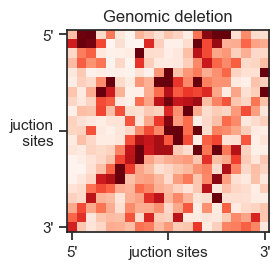

In [5]:
oe_pedv_ric_cell_kr = extract_oe_matrix('PEDV_in_cell.5nt.KR.matrix', res)

sns.set_theme(style="ticks")  
plt.figure(figsize=(12,5))
box_data = []
ma_len = 10
plt.subplot(141)
ma, count, data = apa(oe_pedv_ric_cell_kr, pedv_long_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 5, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'juction sites',"3'"])
plt.yticks([0,ma_len,2*ma_len],["5'",'juction\n sites',"3'"], rotation = 0)
plt.title('Genomic deletion')

In [6]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('PEDV.xlsx', index=True)

In [8]:
pedv_rand_del = np.zeros(len(pedv_long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
pedv_rand_del['S'] = np.random.random_sample(pedv_rand_del.shape[0]) * 27400
pedv_rand_del['E'] = pedv_rand_del['S'] + np.array([x[2] for x in pedv_long_del])        
for i in range(9):     
    rand_i = np.zeros(len(pedv_long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
    rand_i['S'] = np.random.random_sample(rand_i.shape[0]) * 27400
    rand_i['E'] = rand_i['S'] + np.array([x[2] for x in pedv_long_del])
    pedv_rand_del = np.hstack([pedv_rand_del, rand_i])

Text(0.5, 1.0, 'Random')

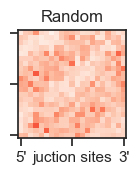

In [9]:
plt.subplot(142)
ma, count, data = apa(oe_pedv_ric_cell_kr, pedv_rand_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 5, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'juction sites',"3'"])
plt.yticks([0,ma_len,2*ma_len],["",'',""], rotation = 0)
plt.title('Random')

In [8]:
virus_bg = list(next(open((file_dir + '1110-mafft-done-NC_045512.fasta'))))
dict_loci = {}
j = 0
for i,x in enumerate(virus_bg):
    if x != '-':
        j += 1
    dict_loci[i] = j

In [12]:
file_in =  open(file_dir + '1110-mafft-done.fasta')
dict_sars2 = {}
for line in file_in:
    lines = list(line)
    if lines[0] == '>':
        key = ''.join(lines[1:-1]).split(' ')[0]
        dict_sars2[key] = [[],[],[],[]]
        if key == 'MN692770.1':
            continue
    else:
        tem_loci = 0
        for i,x in enumerate(lines[:-1]):
            loci = dict_loci[i]
            if loci == tem_loci and x == '-':
                dict_sars2[key][0].append(loci) 
            elif loci != tem_loci and x == '-':
                dict_sars2[key][1].append(loci) 
            elif loci == tem_loci and x != '-':
                dict_sars2[key][2].append(loci) 
            elif loci != tem_loci and x != '-':
                dict_sars2[key][3].append(loci) 
            tem_loci = loci   
file_in.close()

list_del = []
for key in dict_sars2:
    if len(dict_sars2[key][1]) > 1:
        list_del.extend(sites_to_range(dict_sars2[key][1]))      
list_del = [tuple(x) for x in list_del]   
del_count = Counter(list_del) 

long_del = []   
for key in del_count.keys():
    if del_count[key] >= 1 and key[2]>30:
        if key[0] < 75 :
            continue
        if key[1] > 29900:
            continue   
        long_del.append(key)

Text(0.5, 1.0, 'Genomic deletion')

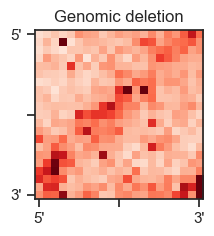

In [13]:
oe_sars_ric_cell_kr = extract_oe_matrix('virus.inCell.Vero.5nt.KR.matrix', res)
sars2_long_del = long_del.copy()   
sns.set_theme(style="ticks")    
plt.figure(figsize=(10,5))
box_data = []
ma_len = 10
plt.subplot(141)
ma, count, data = apa(oe_sars_ric_cell_kr, sars2_long_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 4, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'',"3'"])
plt.yticks([0,ma_len,2*ma_len],["5'",'',"3'"], rotation = 0)
plt.title('Genomic deletion')

In [14]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('SARS-CoV-2.xlsx', index=True)

In [15]:
sars2_rand_del = np.zeros(len(long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
sars2_rand_del['S'] = np.random.random_sample(sars2_rand_del.shape[0]) * 27400
sars2_rand_del['E'] = sars2_rand_del['S'] + np.array([x[2] for x in long_del])        
for i in range(10):     
    rand_i = np.zeros(len(long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
    rand_i['S'] = np.random.random_sample(rand_i.shape[0]) * 27400
    rand_i['E'] = rand_i['S'] + np.array([x[2] for x in long_del])
    sars2_rand_del = np.hstack([sars2_rand_del, rand_i])

sars2_rand_del = sars2_rand_del[:1000]

Text(0.5, 1.0, 'Random')

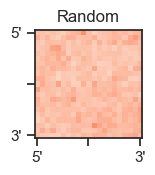

In [16]:
plt.subplot(142)
ma, count, data = apa(oe_sars_ric_cell_kr, sars2_rand_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 4, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'',"3'"])
plt.yticks([0,ma_len,2*ma_len],["5'",'',"3'"], rotation = 0)
plt.title('Random')

In [5]:
mers_nc = list(next(open((file_dir + 'MERS_657_complete_mafft_NC_019843.fasta'))))
dict_loci = {}
j = 0
for i,x in enumerate(mers_nc):
    if x != '-':
        j += 1
    dict_loci[i] = j

In [6]:
list_mers_gap = ['MK378627.1', 'MK378624.1', 'MK378635.1'] #, 'MK378623.1',  'MK378630.1', 'MK378631.1', 'MK378632.1', 'MK378633.1'] 
file_in =  open(file_dir + 'MERS_657_complete_mafft_md.fasta')
dict_mers = {}
for line in file_in:
    lines = list(line)
    if lines[0] == '>':
        key = ''.join(lines[1:-1]).split(' ')[0]        
        if key in list_mers_gap :
            continue
        dict_mers[key] = [[],[],[],[]]
        
    else:
        if key in list_mers_gap :
            continue
        tem_loci = 0
        for i,x in enumerate(lines[:-1]):
            loci = dict_loci[i]
            if loci == tem_loci and x == '-':
                dict_mers[key][0].append(loci) 
            elif loci != tem_loci and x == '-':
                dict_mers[key][1].append(loci) 
            elif loci == tem_loci and x != '-':
                dict_mers[key][2].append(loci) 
            elif loci != tem_loci and x != '-':
                dict_mers[key][3].append(loci) 
            tem_loci = loci       
file_in.close()

list_del = []
for key in dict_mers:
    if len(dict_mers[key][1]) > 1:
        list_del.extend(sites_to_range(dict_mers[key][1]))  
list_del = [tuple(x) for x in list_del]   
del_count = Counter(list_del) 

mers_long_del = []   
for key in del_count.keys():
    if del_count[key] >= 1 and key[2]>=25:
        if key[0] < 75 :
            continue
        if key[1] > 30000:
            continue   
        mers_long_del.append(key)

Text(0.5, 1.0, 'Genomic deletion')

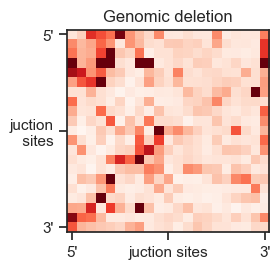

In [8]:
oe_mers_com_cell = extract_oe_matrix('MERS-comrades-PRJNA646969-Huh7-20h-gRNA-KR-5BP.matrix', res)
sns.set_theme(style="ticks")  
plt.figure(figsize=(12,5))
box_data = []
ma_len = 10
plt.subplot(141)
ma, count, data = apa(oe_mers_com_cell, mers_long_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 5, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'juction sites',"3'"])
plt.yticks([0,ma_len,2*ma_len],["5'",'juction\n sites',"3'"], rotation = 0)
plt.title('Genomic deletion')

In [9]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('MERS-CoV.xlsx', index=True)

In [10]:
mers_rand_del = np.zeros(len(mers_long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
mers_rand_del['S'] = np.random.random_sample(mers_rand_del.shape[0]) * 27400
mers_rand_del['E'] = mers_rand_del['S'] + np.array([x[2] for x in mers_long_del])        
for i in range(9):     
    rand_i = np.zeros(len(mers_long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
    rand_i['S'] = np.random.random_sample(rand_i.shape[0]) * 24400
    rand_i['E'] = rand_i['S'] + np.array([x[2] for x in mers_long_del])
    mers_rand_del = np.hstack([mers_rand_del, rand_i])

Text(0.5, 1.0, 'Random')

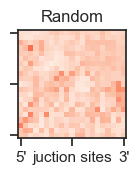

In [11]:
plt.subplot(142)
ma, count, data = apa(oe_mers_com_cell, mers_rand_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 5, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'juction sites',"3'"])
plt.yticks([0,ma_len,2*ma_len],["",'',""], rotation = 0)
plt.title('Random')

In [12]:
pdcov_kt = list(next(open((file_dir + 'PDCoV_549_mafft_sort-KT336560.1.fasta'))))
dict_loci = {}
j = 0
for i,x in enumerate(pdcov_kt):
    if x != '-':
        j += 1
    dict_loci[i] = j

In [13]:
list_pdcov_gap = ['MK378627.1', 'MK378624.1', 'MK378635.1'] #, 'MK378623.1',  'MK378630.1', 'MK378631.1', 'MK378632.1', 'MK378633.1'] 
file_in =  open(file_dir + 'PDCoV_549_mafft_md.fasta')
dict_pdcov = {}
for line in file_in:
    lines = list(line)
    if lines[0] == '>':
        key = ''.join(lines[1:-1]).split(' ')[0]        
        if key in list_pdcov_gap :
            continue
        dict_pdcov[key] = [[],[],[],[]]
        
    else:
        if key in list_pdcov_gap :
            continue
        tem_loci = 0
        for i,x in enumerate(lines[:-1]):
            loci = dict_loci[i]
            if loci == tem_loci and x == '-':
                dict_pdcov[key][0].append(loci) 
            elif loci != tem_loci and x == '-':
                dict_pdcov[key][1].append(loci) 
            elif loci == tem_loci and x != '-':
                dict_pdcov[key][2].append(loci) 
            elif loci != tem_loci and x != '-':
                dict_pdcov[key][3].append(loci) 
            tem_loci = loci     
file_in.close()

list_del = []
for key in dict_pdcov:
    if len(dict_pdcov[key][1]) > 1:
        list_del.extend(sites_to_range(dict_pdcov[key][1]))  
list_del = [tuple(x) for x in list_del]   
del_count = Counter(list_del) 

pdcov_long_del = []   
for key in del_count.keys():
    if del_count[key] >= 1 and key[2]>20 and (key[1] - key[0])<=400:
        if key[0] < 75 :
            continue
        if key[1] > 25350:
            continue   
        pdcov_long_del.append(key)

Text(0.5, 1.0, 'Genomic deletion')

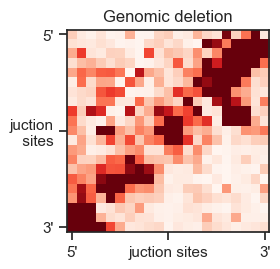

In [15]:
oe_ric_pdcov_cell = extract_oe_matrix('pdcov_in_Cell.5nt.KR.matrix', res)
sns.set_theme(style="ticks")  
plt.figure(figsize=(12,5))
box_data = []
ma_len = 10
plt.subplot(141)
ma, count, data = apa(oe_ric_pdcov_cell, pdcov_long_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 5, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'juction sites',"3'"])
plt.yticks([0,ma_len,2*ma_len],["5'",'juction\n sites',"3'"], rotation = 0)
plt.title('Genomic deletion')

In [16]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('PDCoV.xlsx', index=True)

In [17]:
pdcov_rand_del = np.zeros(len(pdcov_long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
pdcov_rand_del['S'] = np.random.random_sample(pdcov_rand_del.shape[0]) * 27400
pdcov_rand_del['E'] = pdcov_rand_del['S'] + np.array([x[2] for x in pdcov_long_del])        
for i in range(9):     
    rand_i = np.zeros(len(pdcov_long_del), dtype=[('S', '<i4'), ('E', '<i4'), ('value', '<f8')])
    rand_i['S'] = np.random.random_sample(rand_i.shape[0]) * 24400
    rand_i['E'] = rand_i['S'] + np.array([x[2] for x in pdcov_long_del])
    pdcov_rand_del = np.hstack([pdcov_rand_del, rand_i])

Text(0.5, 1.0, 'Random')

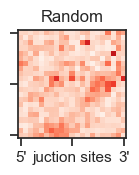

In [18]:
plt.subplot(142)
ma, count, data = apa(oe_ric_pdcov_cell, pdcov_rand_del, 0, 30000, ma_len, res, 'stem')
box_data.append(data)
plt.imshow(ma / count, cmap = plt.get_cmap('Reds'), vmax = 5, vmin = 0)
plt.xticks([0,ma_len,2*ma_len],["5'",'juction sites',"3'"])
plt.yticks([0,ma_len,2*ma_len],["",'',""], rotation = 0)
plt.title('Random')